---
title: "Structuring Unstructured Data: Tokenization, NER & Networks"
toc: true
format: html
jupyter: python3
syntax-highlighting: github
---

In the last lesson, we used Pandas string methods to do some initial exploration of the novel texts in our combined dataset — counting characters, searching for patterns, and comparing pronoun frequencies across genres. These methods are fast and useful, but they treat text as a raw sequence of characters rather than as language.

Today we go a step further. We'll look at what it actually means to **structure** unstructured text data, starting with the foundational concept of *tokenization*, then moving to *Named Entity Recognition* (NER) to extract meaningful entities from our novels, and finally using those entities to build a **network** that captures relationships between characters across our corpus.

---

## From Structured to Unstructured Data

When we looked at the Top 500 Novels dataset, most of the columns were already structured: genres, rankings, publication years. We could group, filter, and plot them directly. But now that we have the full text of each novel in our `eng_text` column, we have **unstructured data** — text that is not easily searchable or analyzable without additional processing.

![](https://i.pinimg.com/736x/b0/04/b5/b004b543748ba1350c5d66c16c678607.jpg)

The challenge of structuring cultural data like this sits at the heart of several overlapping fields:

![](https://miro.medium.com/max/1200/0*ewkxRItArykG27dU.png)

Rather than trying to define all of text analysis at once, it's helpful to make a key distinction between two fundamental goals:

**Information Retrieval (IR)** first developed in the 1950s and 1960s (think Vannevar Bush and the Memex!) and its goal is to find relevant documents for a user's needs or queries. IR doesn't necessarily require *understanding* the content of documents — it can treat them as a "bag of words" and find patterns in word frequencies.

![](../../assets/images/IR_figure.png)

**Information Extraction (IE)** is different. Rather than finding documents, it extracts specific structured facts *from* documents — things like who is mentioned, what organizations are named, what events are described. It requires understanding both syntax and semantics.

![](../../assets/images/IE_figure.png)

Both approaches require a common first step: **tokenization**.

---

## Tokenization

Tokenization is the process of breaking text into smaller units called *tokens*, which can be words, phrases, or characters. Before we can count words, find named entities, or build any model over text, we need to decide how to divide it up.

![](https://miro.medium.com/v2/resize:fit:2000/1*pj8KnjxgCszpDqJSS2741w.jpeg)

The field of corpus linguistics replaced the informal term "word" with the more precise terms **token** (a specific occurrence in a text) and **type** (the abstract word form). For example, "run," "running," and "ran" are three different tokens but they all belong to the same type. This distinction matters a lot for analysis.

### Why Tokenization Matters: Zipf's Law

One of the most important scholars in this area was George Zipf, who in the 1930s discovered that in any corpus, the most common word appears roughly twice as often as the second most common, three times as often as the third, and so on. This distribution is known as **Zipf's Law**.

Zipf actually discovered this pattern while analyzing James Joyce's *Ulysses* — one of the first computational humanities projects! It tells us that a small number of words dominate any text, which has major implications for analysis. When we look at word frequencies, we'll always see common function words (the, and, of, in) swamping everything else unless we handle them deliberately.

We can explore this with NLTK (remember to `pip install nltk`):

<Axes: xlabel='Samples', ylabel='Counts'>

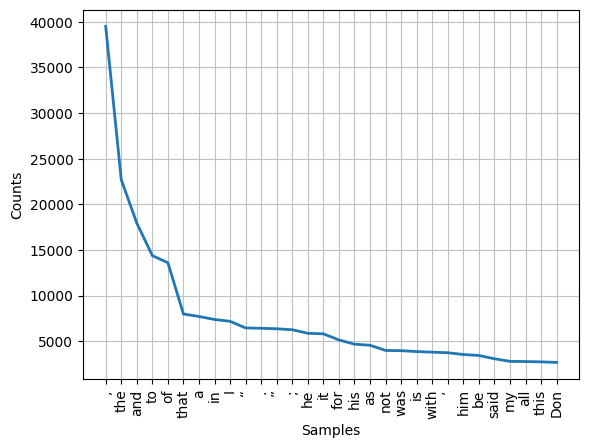

In [1]:
import pandas as pd
from nltk import word_tokenize, FreqDist

# Load the pre-scraped combined dataset
combined_novels_nyt_df = pd.read_csv("combined_novels_with_text.csv")

# Look at token frequency in the first two novels
tokens = FreqDist(sum(
    combined_novels_nyt_df[0:2]['eng_text'].dropna().map(word_tokenize),
    []
))
tokens.plot(30)

This will show the characteristic "long tail" distribution of Zipf's Law — a few words with very high frequency, and then a sharp dropoff.

### Tokenization Choices Are Interpretive Choices

There is no single "correct" way to tokenize text. Every choice shapes your analysis:

- **Lowercasing** — should "The" and "the" count as the same token?
- **Punctuation** — removing it simplifies counting but loses information (question marks, em-dashes)
- **Stemming vs. lemmatization** — reducing "running" to "run" normalizes forms, but collapses distinctions
- **Stop words** — common words like "the" and "of" often overwhelm analyses and get removed, but the choice of which words to remove is itself interpretive
- **Bigrams** — sometimes two-word phrases ("New York", "not good") carry more meaning than single tokens

Let's compare two approaches on our data. First, a simple space-split:

In [2]:
combined_novels_nyt_df['word_count_split'] = combined_novels_nyt_df['eng_text'].str.split().str.len()

Then NLTK's word tokenizer, which is smarter about punctuation and contractions:

In [3]:
def tokenize_text(text):
    if pd.notna(text):
        return word_tokenize(text)
    return []

combined_novels_nyt_df['tokens'] = combined_novels_nyt_df['eng_text'].apply(tokenize_text)
combined_novels_nyt_df['word_count_nltk'] = combined_novels_nyt_df['tokens'].apply(len)

# Compare the two
combined_novels_nyt_df[['title', 'word_count_split', 'word_count_nltk']].head(10)

,title,word_count_split,word_count_nltk
0,Don Quixote,430284.0,499451
1,Alice's Adventures in Wonderland,29569.0,38440
2,The Adventures of Huckleberry Finn,NaN,0
3,The Adventures of Tom Sawyer,73849.0,93907
4,Treasure Island,71671.0,88946
5,Pride and Prejudice,130415.0,154451
6,Wuthering Heights,118978.0,149687
7,Jane Eyre,188435.0,231736
8,Moby Dick,215845.0,262129
9,The Scarlet Letter,86883.0,105110


You'll find the NLTK counts are slightly higher, because it correctly separates punctuation attached to words (like "said." becoming "said" and ".").

### Stop Words

*Stop words* are the most common words in a language, and they are often removed from text data because they don't carry much content meaning. The term was coined by Hans Peter Luhn in 1958, when he was developing the concept of Keywords In Context (KWIC) indexing.

<table>
  <tr>
    <td>
      ![](../../assets/images/luhn_paper.png)
    </td>
    <td>
      ![](../../assets/images/kwic_example.png)
    </td>
  </tr>
  <tr>
    <td colspan="2" style="text-align: center;">
      Images from Luhn, H. P. "Key Word-in-Context Index for Technical Literature (Kwic Index)." <em>American Documentation</em> 11, no. 4 (1960): 288–95. <a href="https://doi.org/10.1002/asi.5090110403">https://doi.org/10.1002/asi.5090110403</a>.
    </td>
  </tr>
</table>

NLTK has a built-in stop words list:

In [6]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stop_words(text):
    if pd.notna(text):
        return ' '.join([w for w in text.split() if w.lower() not in stop_words])
    return text

combined_novels_nyt_df['text_no_stopwords'] = combined_novels_nyt_df['eng_text'].apply(remove_stop_words)

However, this is another interpretive decision. For example, "not" is on the NLTK stop words list, but it's clearly important for sentiment analysis. We've also discussed earlier in the course how crude filtering lists can inadvertently remove content from marginalized communities. Before removing stop words, always inspect the list and consider what you might be losing.

In [7]:
# You can remove specific words from the stop list
stop_words.discard('not')

---

## Named Entity Recognition (NER)

Now that we have a sense of how to structure text at the word level, we can move to something more powerful: extracting *named entities* — the people, places, organizations, and other specific referents that appear in a text.

From [Wikipedia](https://en.wikipedia.org/wiki/Named-entity_recognition):

> "Named-entity recognition (NER) is a subtask of information extraction that seeks to locate and classify named entities mentioned in unstructured text into pre-defined categories such as person names, organizations, locations, medical codes, time expressions, quantities, monetary values, percentages, etc."

![spacy ner](https://miro.medium.com/max/1400/0*zDbB-LV-Dlm_F_PX)

The concept of "named entity" first developed at the Message Understanding Conference-6 in 1995. The field really takes off with the Text Analysis Conferences beginning in 2009 and has since become central to computational humanities — for example, in the Data-Sitters Club article we read, the authors used NER to track character mentions across multilingual translations of *The Baby-Sitters Club* series.

### NER with spaCy

We'll use [spaCy](https://spacy.io/), a powerful and widely used NLP library. First, install it and download the English model:

```shell
pip install spacy
python -m spacy download en_core_web_sm
```

Now let's load the library and try a quick example:

In [8]:
import spacy
nlp = spacy.load('en_core_web_sm')

doc = nlp("Apple is looking at buying U.K. startup for $1 billion")

for ent in doc.ents:
    print(ent.text, ent.start_char, ent.end_char, ent.label_)

Apple 0 5 ORG
U.K. 27 31 GPE
$1 billion 44 54 MONEY


We should see:

```
Apple 0 5 ORG
U.K. 27 31 GPE
$1 billion 44 54 MONEY
```

This is telling us the text of the entity, its character positions in the document, and its label. spaCy uses the following entity types among others:

![ner entities](https://devopedia.org/images/article/256/8660.1580659054.png)

### How spaCy Works

spaCy uses a pipeline of statistical models to process text:

![spacy pipeline](https://d33wubrfki0l68.cloudfront.net/3ad0582d97663a1272ffc4ccf09f1c5b335b17e9/7f49c/pipeline-fde48da9b43661abcdf62ab70a546d71.svg)

The key thing to understand is that spaCy's NER is based on trained machine learning models — it makes predictions about which label most likely applies based on patterns learned from large annotated datasets. This means it can generalize well to new text, but it also inherits the biases and limitations of its training data. 

We can also visualize how spaCy is analyzing a sentence using its built-in `displacy` visualizer:

In [9]:
from spacy import displacy

doc = nlp("Elizabeth Bennet and Mr. Darcy meet at Netherfield in Hertfordshire.")
displacy.render(doc, style="ent")

### Applying NER to Our Novels

Now let's apply NER to our novel texts. Since spaCy needs to process each text individually, we'll write a function and use `apply()`:

In [10]:
def get_entities(text, entity_type='PERSON'):
    """Extract all entities of a given type from a text."""
    if pd.notna(text) and len(str(text)) > 0:
        # Limit to first 100,000 characters to keep things fast
        doc = nlp(str(text)[:100000])
        return [ent.text for ent in doc.ents if ent.label_ == entity_type]
    return []

# Extract person entities from each novel
# This will take a few minutes — a good time to grab coffee!
combined_novels_nyt_df['person_entities'] = combined_novels_nyt_df['eng_text'].apply(
    lambda x: get_entities(x, 'PERSON')
)

::: {.callout-tip}
Processing full novel texts through spaCy's pipeline is slow. For in-class work, it's fine to limit to the first 100,000 characters of each text, or to work with a small subset of novels. The code above uses that character limit.
:::

Now let's take a look at what entities were found in a few novels:

In [11]:
for _, row in combined_novels_nyt_df[0:5].iterrows():
    print(f"\n{row['title']} by {row['author']}")
    # Show the 10 most common person entities
    from collections import Counter
    entity_counts = Counter(row['person_entities'])
    print(entity_counts.most_common(10))


Don Quixote by Miguel de Cervantes
[('Cervantes', 80), ('Don Quixote', 9), ('Dey', 8), ('Shakespeare', 5), ('Don John', 5), ('Avellaneda', 5), ('DON QUIXOTE', 4), ('Shelton', 4), ('Salamanca', 4), ('Alcalá', 4)]

Alice's Adventures in Wonderland by Lewis Carroll
[('Alice', 237), ('Hatter', 33), ('Mouse', 26), ('Queen', 11), ('Pigeon', 9), ('Bill', 8), ('William', 6), ('Mabel', 4), ('Mary Ann', 4), ('Said', 3)]

The Adventures of Huckleberry Finn by Mark Twain
[]

The Adventures of Tom Sawyer by Mark Twain
[('Tom', 171), ('Sid', 21), ('Mary', 18), ('Jim', 15), ('Tom’s', 12), ('Ben', 12), ('Tom Sawyer', 7), ('Huck', 7), ('Ting', 7), ('Joe', 7)]

Treasure Island by Robert Louis Stevenson
[('Livesey', 24), ('Bill', 21), ('Jim', 21), ('Hawkins', 13), ('Dance', 12), ('Trelawney', 11), ('Benbow', 7), ('Livesey’s', 7), ('Arrow', 7), ('Smollett', 6)]


You'll immediately notice something important: spaCy is imperfect. It might tag "Mr." or "Chapter" as a PERSON, or miss characters referred to only by pronoun. This is a known limitation of statistical NER on literary texts, where characters may be addressed differently throughout a novel (by name, title, nickname, or pronoun). This is exactly the problem the Data-Sitters Club authors grappled with in their multilingual analysis.

### Building a Named Entities DataFrame

Rather than keeping entities as lists inside our existing DataFrame, it's often more useful to create a separate **entities DataFrame** — one row per entity mention — which we can then analyze and merge back in:

In [12]:
entity_rows = []

for _, row in combined_novels_nyt_df.iterrows():
    for entity in row['person_entities']:
        entity_rows.append({
            'title': row['title'],
            'author': row['author'],
            'genre': row['genre'],
            'pub_year': row['pub_year'],
            'entity': entity
        })

entities_df = pd.DataFrame(entity_rows)
print(entities_df.shape)
entities_df.head(10)

(50615, 5)


,title,author,genre,pub_year,entity
0,Don Quixote,Miguel de Cervantes,action,1605,Miguel de Cervantes Saavedra\r\n\r\n
1,Don Quixote,Miguel de Cervantes,action,1605,John Ormsby\r\n\r\n\r\n \r\nRelease
2,Don Quixote,Miguel de Cervantes,action,1605,David Widger
3,Don Quixote,Miguel de Cervantes,action,1605,Full Size\r\n\r\n\r\n\r\n\r\n\r\n\r\nDon Quixote
4,Don Quixote,Miguel de Cervantes,action,1605,Miguel de Cervantes\r\n\r\n\r\n\r\n Translated
5,Don Quixote,Miguel de Cervantes,action,1605,John Ormsby
6,Don Quixote,Miguel de Cervantes,action,1605,Ormsby
7,Don Quixote,Miguel de Cervantes,action,1605,J. W. Clark
8,Don Quixote,Miguel de Cervantes,action,1605,Gustave Doré
9,Don Quixote,Miguel de Cervantes,action,1605,Clark


Now we can ask questions like: which person entities appear most frequently across the entire corpus?

In [13]:
entities_df['entity'].value_counts().head(20)

entity
Stephen          933
Buck Mulligan    585
Tom              519
Anne             513
Alice            486
Catherine        351
Peter            344
Deasy            315
John             296
Henry            275
Joe              267
Heidi            250
Mary             232
Scrooge          204
Buck             200
Philip           185
Charles          182
Kim              182
Lucy             179
Harding          174
Name: count, dtype: int64

Or which entities are most common within each genre?

In [14]:
entities_df.groupby(['genre', 'entity']).size().reset_index(name='count').sort_values('count', ascending=False).groupby('genre').head(5)

,genre,entity,count
8475,na,Stephen,885
4532,na,Buck Mulligan,585
1534,fantasy,Alice,466
4138,na,Anne,444
5047,na,Deasy,315
5911,na,Heidi,250
1329,bildung,Philip,185
1136,bildung,Joe,185
74,action,Buck,184
337,action,Kim,182


---

## From NER to Networks

Now we get to one of the most powerful applications of NER: using extracted entities to build a **network** that represents relationships across a corpus.

The basic idea comes from *The Network Turn* (which we read earlier in the course): networks are an abstraction that let us represent and compute over relationships between entities. A network has two components:

- **Nodes** — the entities (in our case, character names)
- **Edges** — connections between entities (in our case, co-occurrence: two characters appearing in the same novel)

As the authors of *The Network Turn* note:

> Nothing is naturally a network; rather, networks are an abstraction into which we squeeze the world. Nevertheless, almost anything can be turned into a network.

The key interpretive question is: what counts as a relationship? We'll start with the simplest approach — two characters are "connected" if they both appear in the same novel. Later you might want to use a sliding window approach (characters co-occurring within N words of each other), which captures more local interaction patterns.

### Creating a Co-Occurrence Network

Let's build a network where nodes are the most common named persons across our corpus, and edges connect characters who appear in the same novel.

First, let's identify the most frequently occurring entities to use as our nodes, filtering out noise:

In [15]:
# Get the top 50 most common entity names across the corpus
top_entities = entities_df['entity'].value_counts().head(50).index.tolist()

# Filter our entities DataFrame to just these
filtered_entities_df = entities_df[entities_df['entity'].isin(top_entities)]

Now we'll build an edge list. For each novel, any two entities that appear together create an edge (or strengthen an existing one):

In [16]:
from itertools import combinations
import networkx as nx

edge_counts = {}

for title, group in filtered_entities_df.groupby('title'):
    # Get unique entities in this novel
    novel_entities = group['entity'].unique().tolist()
    # Create edges for all pairs
    for entity1, entity2 in combinations(novel_entities, 2):
        pair = tuple(sorted([entity1, entity2]))
        edge_counts[pair] = edge_counts.get(pair, 0) + 1

# Convert to a DataFrame
edges_df = pd.DataFrame(
    [(e1, e2, w) for (e1, e2), w in edge_counts.items()],
    columns=['source', 'target', 'weight']
)

print(f"Number of edges: {len(edges_df)}")
edges_df.sort_values('weight', ascending=False).head(10)

Number of edges: 304


,source,target,weight
63,James,John,9
96,Harry,Tom,8
73,Bill,Jim,6
19,John,Joseph,6
18,John,Mary,6
9,Charles,John,5
21,Joe,Tom,5
33,Jane,Mary,5
84,Dick,Tom,5
31,Mary,Peter,5


Now we can create a `networkx` graph from this edge list:

In [17]:
import matplotlib.pyplot as plt

G = nx.from_pandas_edgelist(edges_df, source='source', target='target', edge_attr='weight')

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 48
Edges: 304


### Visualizing the Network

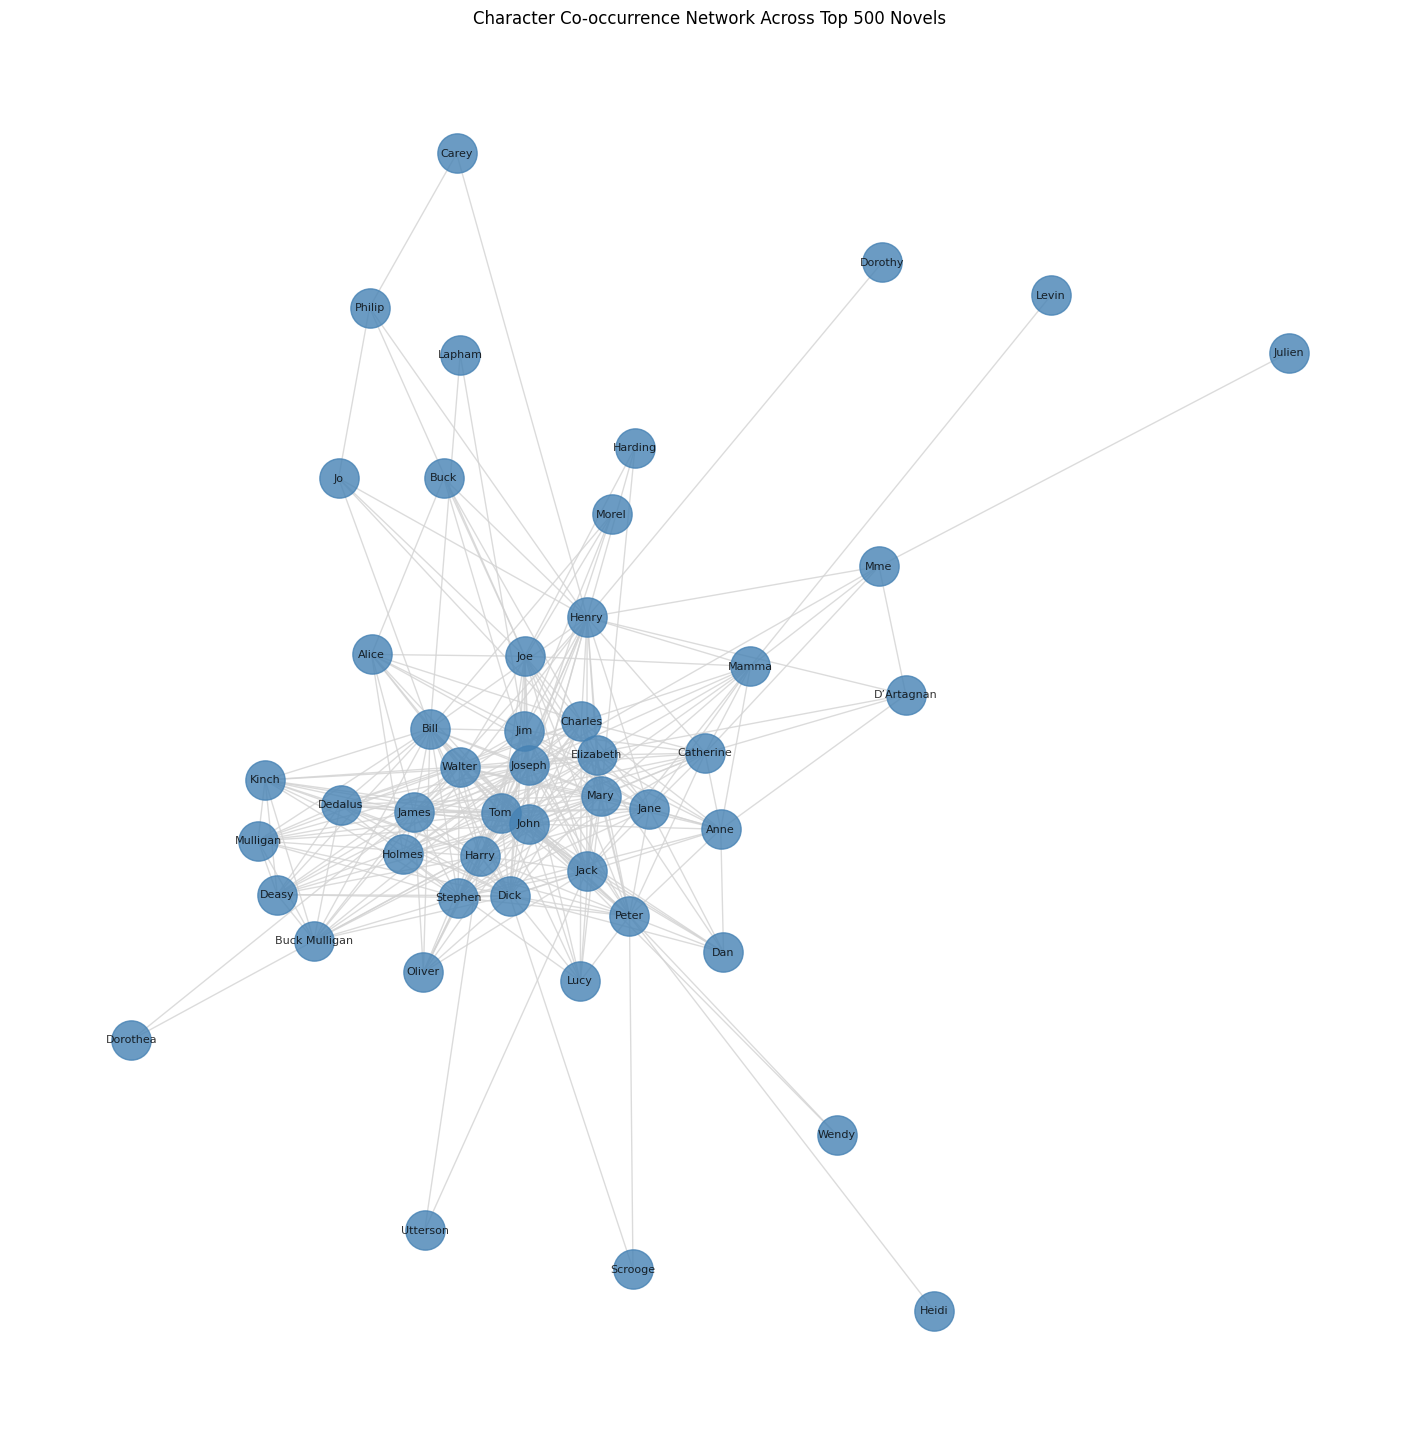

In [18]:
plt.figure(figsize=(14, 14))
nx.draw(
    G,
    with_labels=True,
    font_size=8,
    node_size=800,
    node_color='steelblue',
    edge_color='lightgray',
    alpha=0.8
)
plt.title("Character Co-occurrence Network Across Top 500 Novels")
plt.show()

You'll see a force-directed graph where nodes that are more central tend to be pulled toward the middle. But we can do better than a generic layout — let's use network algorithms to surface what's actually interesting.

### Network Centrality

Network analysis gives us computational measures of how important each node is. Two of the most useful:

- **Degree centrality** — how many other nodes does this node connect to? A high degree means an entity co-occurs with many others.
- **Betweenness centrality** — how often does this node lie on the shortest path between two other nodes? High betweenness means an entity is a "bridge" between otherwise disconnected parts of the network.

In [19]:
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

# Build a summary DataFrame
centrality_df = pd.DataFrame({
    'entity': list(degree_centrality.keys()),
    'degree_centrality': list(degree_centrality.values()),
    'betweenness_centrality': [betweenness_centrality[n] for n in degree_centrality.keys()]
}).sort_values('degree_centrality', ascending=False)

print("Top 10 by Degree Centrality:")
print(centrality_df.head(10))

print("\nTop 10 by Betweenness Centrality:")
print(centrality_df.sort_values('betweenness_centrality', ascending=False).head(10))

Top 10 by Degree Centrality:
    entity  degree_centrality  betweenness_centrality
10    John           0.702128                0.118105
3   Joseph           0.638298                0.108241
13     Tom           0.553191                0.027644
0     Dick           0.510638                0.036303
6    Harry           0.510638                0.039335
15    Bill           0.489362                0.053142
11    Mary           0.489362                0.026728
23   James           0.489362                0.030297
7    Henry           0.468085                0.137090
2    Peter           0.468085                0.081778

Top 10 by Betweenness Centrality:
    entity  degree_centrality  betweenness_centrality
7    Henry           0.468085                0.137090
10    John           0.702128                0.118105
3   Joseph           0.638298                0.108241
2    Peter           0.468085                0.081778
15    Bill           0.489362                0.053142
17   Mamma        

The two measures often highlight different entities. A character like "God" might have very high degree centrality (appearing across many novels) but low betweenness centrality (not bridging distinct communities). Conversely, an entity that bridges, say, a cluster of 19th-century novels and a cluster of 20th-century ones might rank highly on betweenness even if it doesn't appear in that many books.

We can visualize the network with node size proportional to degree centrality:

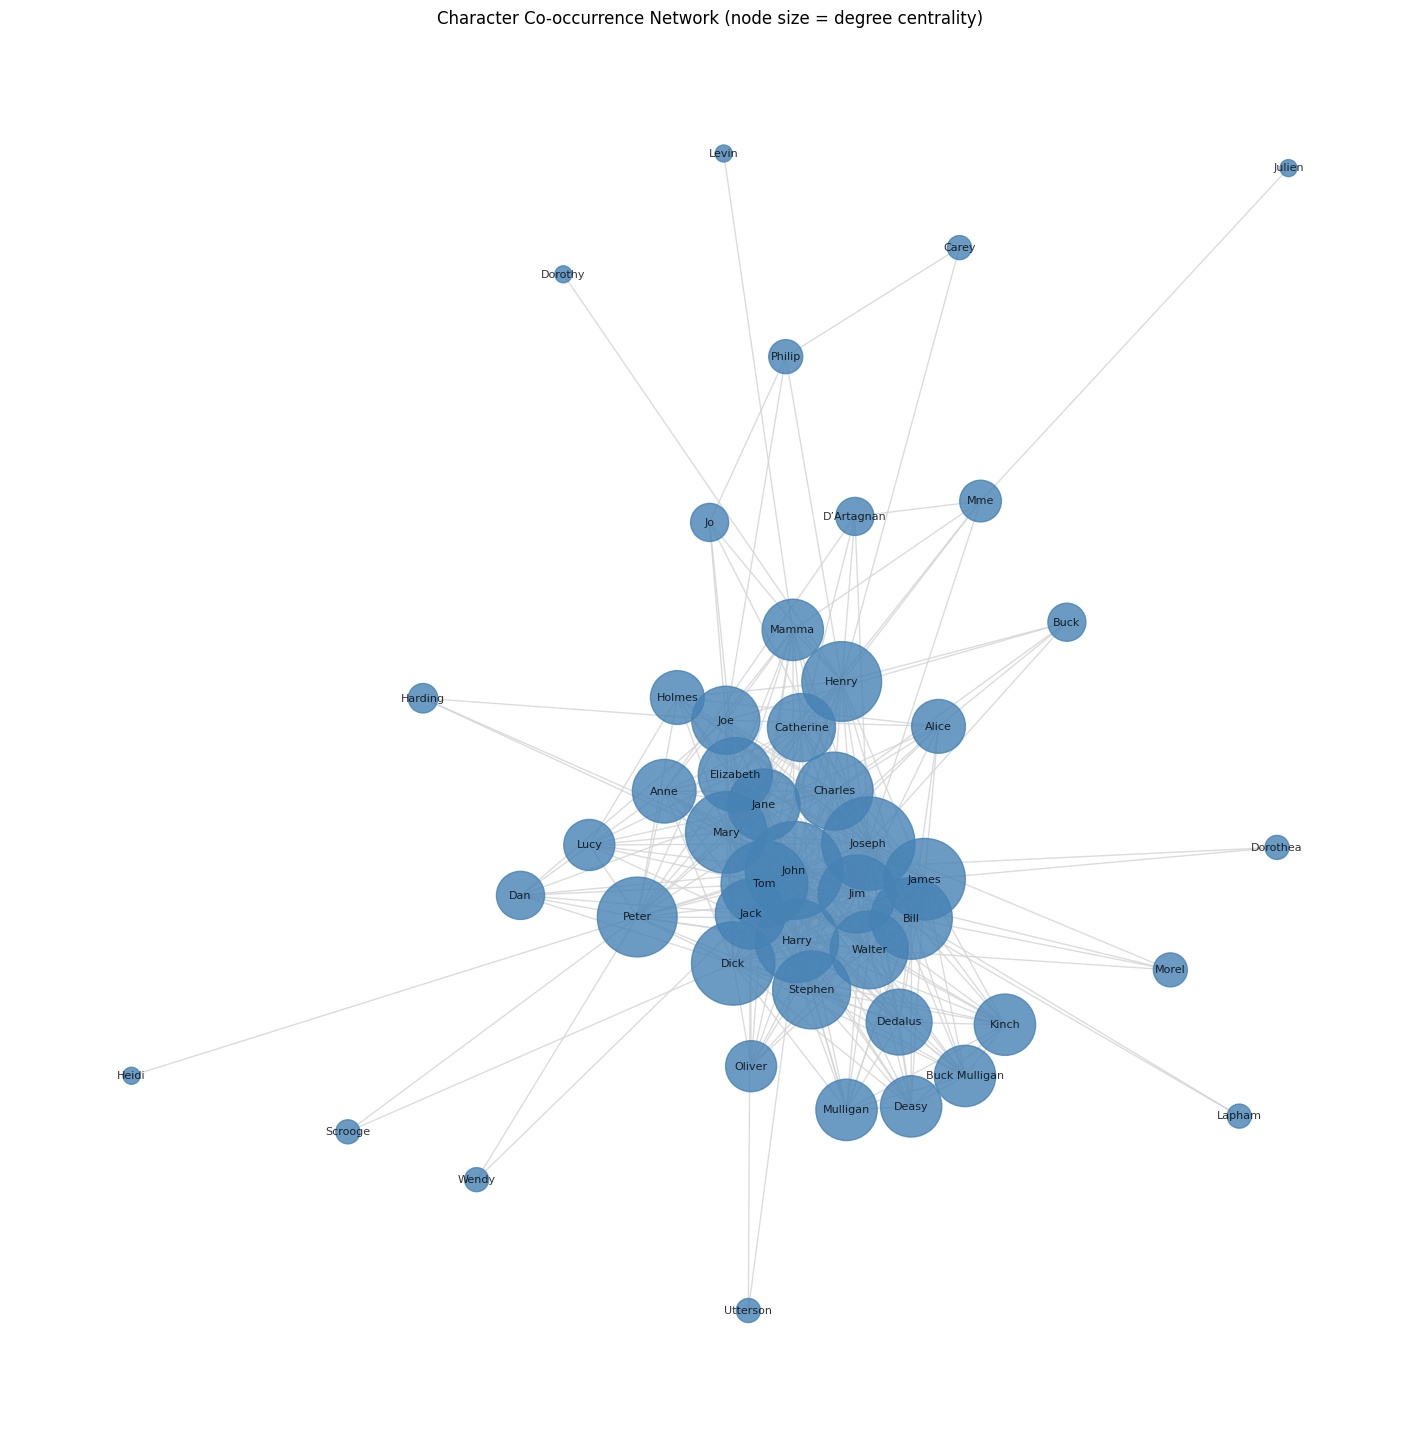

In [20]:
plt.figure(figsize=(14, 14))
node_sizes = [G.degree(v) * 150 for v in G]
nx.draw(
    G,
    with_labels=True,
    font_size=8,
    node_size=node_sizes,
    node_color='steelblue',
    edge_color='lightgray',
    alpha=0.8
)
plt.title("Character Co-occurrence Network (node size = degree centrality)")
plt.show()

### Community Detection

Beyond individual nodes, we can also look for **communities** — groups of nodes that are more densely connected to each other than to the rest of the network. The Louvain algorithm is a popular method for this:

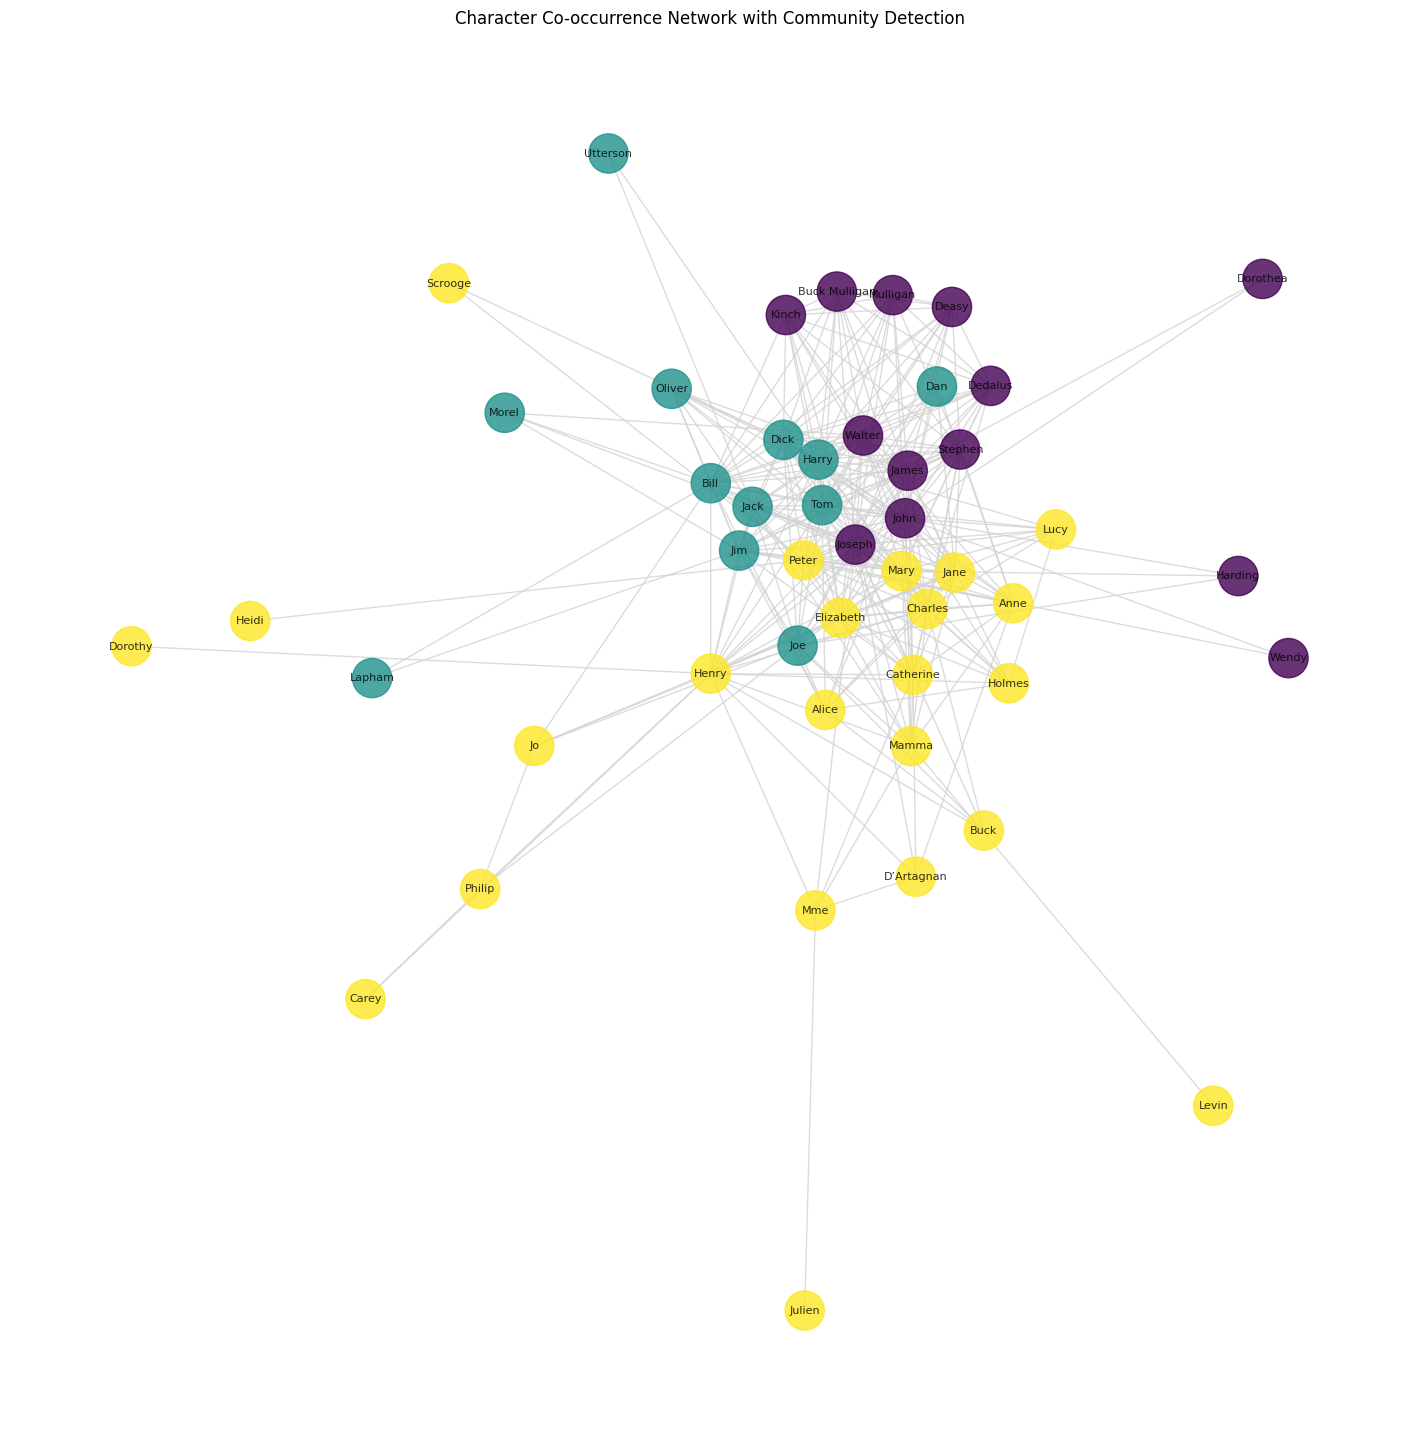

In [21]:
from networkx.algorithms import community

communities = community.louvain_communities(G, seed=42)

# Map each node to its community number
community_map = {}
for i, com in enumerate(communities):
    for node in com:
        community_map[node] = i

colors = [community_map[node] for node in G.nodes()]

plt.figure(figsize=(14, 14))
nx.draw(
    G,
    node_color=colors,
    with_labels=True,
    font_size=8,
    node_size=800,
    edge_color='lightgray',
    alpha=0.8
)
plt.title("Character Co-occurrence Network with Community Detection")
plt.show()

Each color represents a detected community. Do the communities correspond to anything meaningful — a genre, a time period, a set of canonically linked authors? This is where the computational result becomes a *humanities* result: the network hands you a pattern, and you have to interpret it.

---

## Interpreting Networks as Cultural Humanists

At this point it's worth stepping back to think critically about what our network actually represents. The authors of *The Network Turn* warn us that:

> We move across a landscape of abstraction, which entails more information loss the further we travel.

Our network has made several interpretive choices, each of which loses something:

1. **Entity extraction** — spaCy makes errors, especially on literary texts. "Mr." may be tagged as a person; a character's nickname may not match their full name.
2. **Filtering to top entities** — by keeping only the 50 most common names, we've already shaped what the network can see.
3. **Co-occurrence at the novel level** — two characters are "connected" because they appear in the same book, not because they interact directly. This is a very coarse definition of relationship.
4. **Treating all co-occurrences as equal** — the edge between "Elizabeth" and "Darcy" in *Pride and Prejudice* carries a very different meaning than two names that both happen to appear in a long Victorian novel.

None of these choices are wrong — they are tradeoffs. The question is whether the pattern that emerges at this level of abstraction is still meaningful for your research question.

::: {.callout-note}
## A Note on Gazetteers and Rules-Based NER
One way to improve NER for literary texts is to supplement spaCy's statistical model with a **gazetteer** — a pre-compiled list of known entities. For example, if we had a list of character names for each novel, we could add those to spaCy as rules so it always recognizes them correctly. You can read more about this approach in William Mattingly's textbook <http://ner.pythonhumanities.com/02_rules_based_ner.html> and the spaCy documentation on the `EntityRuler` <https://spacy.io/api/entityruler>.
:::

---

## Structuring Unstructured Data Homework

Now that you've learned the pipeline from raw text → tokens → entities → networks, this assignment asks you to apply and extend these methods to our novels corpus. Create a new Jupyter Notebook in your `is310-coding-assignments` repository in a folder called `text-analysis`.

Your notebook should work with the combined novels dataset and accomplish the following:

1. **Tokenization exploration** — Compare at least two tokenization strategies (e.g., split vs. NLTK's `word_tokenize`) on a subset of novels. Visualize the differences using Altair and write a short interpretation of what you notice.

2. **NER and entity analysis** — Apply spaCy's NER to at least 10 novels of your choice. Create an entities DataFrame and use Altair to visualize some pattern you find interesting in the extracted entities. Consider: which entity types are most common? Are there genre differences? Are there any obvious errors in spaCy's output, and what might cause them?

3. **Network analysis** — Build a co-occurrence network from your entity data and calculate at least one centrality measure. Visualize the network and write a 2–3 sentence interpretation of what the structure reveals — and what limitations you see in the approach.

As before, your notebook should be clearly organized with Markdown headers, and should include prose interpreting each step, not just code. There are no right or wrong answers — what matters is that you are thinking critically about the choices involved at each step.

Once complete, push your code to GitHub and post a link in the GitHub discussion [https://github.com/CultureAsData-UIUC/is310-fall-2024/discussions/12](https://github.com/CultureAsData-UIUC/is310-fall-2024/discussions/12).

---

[^1]: Burns, Patrick J. "Constructing Stoplists for Historical Languages." *Digital Classics Online*, December 5, 2018, 4–20. [https://doi.org/10.11588/dco.2018.2.52124](https://doi.org/10.11588/dco.2018.2.52124).